# Tutorial 3: Large rasters

This tutorial demonstrates `floodsr` with a larger raster and an end-to-end CLI run that fetches HRDEM and writes the super-resolved output in one shot.

**What you'll do:**
- verify the extended install from {ref}`extended_install`
- download and visualize a larger test raster
- run `floodsr tohr` with `--fetch-hrdem`
- inspect both the fetched HRDEM and final output


## Install `floodsr`

This tutorial requires the extended install described in {ref}`extended_install`.
`floodsr` uses this two-level installation approach to support as many users as possible:
- the **basic** install for those who need something easy to install and dont need the extra machinery for handling large rasters, and
- the **extended** install for those more comfortable with Python and who want to use the full power of `floodsr` for large rasters.


If you followed the instructions for the {ref}`basic_install`, the simplest way to upgrade is to install a new environment per {ref}`extended_install`.

And you should probably uninstall the old/previous **basic** environment to avoid confusion and free up disk space. 
See {ref}`installation` for install and uninstall commands for each mode and execution context.

Proceed with {ref}`extended_install` based on your execution context:
- **command line (CLI)**: copy and paste the commands from {ref}`extended_install_cli` into your terminal.
- **local notebook (Jupyter)**: follow the same {ref}`extended_install_cli` as for the CLI, then run the additional steps from {ref}`extended_install_notebook` so this notebook uses the correct kernel.
- **hosted notebook (Colab)**: Probably a bad idea. but see {ref}`extended_install_hosted_notebook`, or uncomment the experimental setup cell below if you're feeling brave.


In [1]:
# Colab experimental setup
# !apt-get update -qq
# !apt-get install -y -qq gdal-bin libgdal-dev
# !pip install -q --upgrade pip
# !pip install -q "gdal[numpy]==$(gdal-config --version).*" rasterio geopandas pyproj shapely fiona
# !pip install -q floodsr


## Prove the install

Let's check the versions now:

In [2]:
import matplotlib
import rasterio
import sys

print(f"matplotlib=={matplotlib.__version__}")
print(f"rasterio=={rasterio.__version__}")
print(f"python={sys.executable}")

matplotlib==3.10.8
rasterio==1.5.0
python=/opt/conda/envs/dev/bin/python


In [3]:
!floodsr --version

floodsr 0.0.0


If these don't work, double check you selected correct kernel (e.g., `Python (floodsr-gdal)`) for this notebook. 

## Imports

In [4]:
import os
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.enums import Resampling


## Set Cache

When rasters become large, caching downloads to disk can be a huge time saver. 

By default, this notebook follows the same cache behavior as the source code: if no cache override is supplied, `floodsr` uses your platform default cache directory (e.g., `~/.cache/floodsr` on Linux or `C:\Users\<you>\AppData\Local\Temp` on Windows).
The size required by the cache (and your working directory for that matter) will of course depend on the size of the rasters you work with, but for large rasters, it can be tens of GBs or more.

If you want to override that behavior, edit the below cell and set `base_cache_dir` to a path you want `floodsr` to reuse.

In [5]:
# Edit this cell if you want to override the default cache behavior.
base_cache_dir = os.getenv("FLOODSR_SHARED_CACHE_DIR")

# windows example. un-comment and edit as needed.
# base_cache_dir = r"C:\Users\<you>\floodsr_cache"


In [6]:
if base_cache_dir is not None:
    base_cache_dir = Path(base_cache_dir).expanduser().resolve()
    base_cache_dir.mkdir(parents=True, exist_ok=True)


if base_cache_dir is None:
    print("cache_dir=None -> floodsr will use its default platform cache")
else:
    print(f"cache_dir overridden to {base_cache_dir}")

cache_dir overridden to /workspace/_cache


## Set Paths

let's start by setting some paths to python variables for convenience

In [7]:
# Define the low-res input name and the derived output paths.
lowres_name = "inunriver_historical_000000000WATCH_1980_rp01000.tif"
hrdem_fp = Path(f"{Path(lowres_name).stem}_fetched_hrdem.vrt").resolve()
requested_result_fp = Path("result.tif").resolve()
result_fp = requested_result_fp

print(f"hrdem_fp={hrdem_fp}")
print(f"result_fp={result_fp}")

hrdem_fp=/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_3-ciRI8D/run/inunriver_historical_000000000WATCH_1980_rp01000_fetched_hrdem.vrt
result_fp=/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_3-ciRI8D/run/result.tif


## Download Test Data

For this tutorial, we use a tile from the old [Aqueduct Floods Hazard Maps](https://wri-projects.s3.amazonaws.com/AqueductFloodTool/download/v2/index.html) dataset.

A clip of this has been uploaded to our project repo for easy retrieval.
Fetch it into your working directory using the `urlretrieve` utility function again.




In [8]:
lowres_fp = Path(lowres_name).resolve()

urlretrieve(
    "https://github.com/cefect/floodsr/releases/download/v0.0.9/inunriver_historical_000000000WATCH_1980_rp01000.tif",
    lowres_fp,
)
assert lowres_fp.is_file(), f"could not find {lowres_fp}"

This fetches a raster like:

![Aqueduct screenshot](img/tutorial_3_aqueduct_screenshot.png)


We can also plot it to get a sense of the input data.

lowres_fp: size=0.0 MB, shape=(30, 60), res=(0.008333333333333333, 0.008333333333333333), crs=EPSG:4326


Text(0.5, 1.0, 'Low-res input depth')

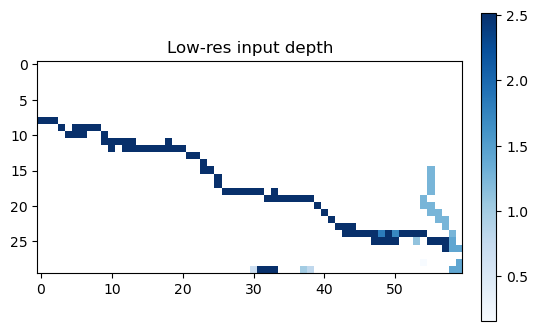

In [ ]:
with rasterio.open(lowres_fp) as src: # no helper function here because we need fancier loading below
    lowres = src.read(1).astype(float)
    if src.nodata is not None:
        lowres[lowres == src.nodata] = np.nan

    # print out some info about the input raster
    print(f"lowres_fp: size={Path(lowres_fp).stat().st_size / 1024**2:.1f} MB, shape={src.shape}, res={src.res}, crs={src.crs}")


plt.figure(figsize=(6, 4))
im = plt.imshow(np.where(lowres > 0, lowres, np.nan), cmap="Blues")
plt.colorbar(im, fraction=0.046, pad=0.04)
_ = plt.title(f"Low-res input depth")
 

yuck

you'll notice this raster uses `EPSG:4326`, which is lat/lon coordinates. Hence the goofy resolution. 
We'll want to keep this in mind when we set our `--crs-policy`.

## Fetch HRDEM and Run `tohr`

For this larger example, we use one CLI command to fetch HRDEM, resolve the model, and run super-resolution in one shot.
The fetched HRDEM is projected (`EPSG:3979`) while the low-res depth raster is geographic (`EPSG:4326`), so we pass `--crs-policy=use-dem` to reproject the depth raster onto the DEM grid.
The `--fetch-out` argument keeps a copy of the fetched HRDEM so we can inspect it in the next section.

If you left `base_cache_dir` as `None`, this command uses the default `floodsr` cache location.


In [ ]:
# Run the one-shot fetch + super-resolution command through the notebook CLI.
cache_dir_arg = "" if base_cache_dir is None else f" --cache-dir {base_cache_dir}"
!floodsr tohr --in {lowres_fp} -f --fetch-out hrdem.vrt --fetch-force-tiling{cache_dir_arg} --window-method hard --crs-policy use-dem --out result.tif --min-depth-threshold=0.1


INFO:floodsr.cli:starting DEM fetch
  source_id=hrdem
  stac_url=https://datacube.services.geo.ca/api
  collection=hrdem-mosaic-1m
  asset_key=dtm
  gdal_available=True
  force_tiling=True
  fetch_window_size=8192
  memory_limit_gib=16.00
  stac_query_limit=200
  use_project_extent_filter=True
  use_cache=True
  cache_dir=/workspace/_cache
  show_progress=True
  project_extent_url=https://maps-cartes.services.geo.ca/server_serveur/rest/services/NRCan/coverage_HRDEM_en/MapServer/4
  depth_lr_fp=
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_3-ciRI8D/run/inunriver_historical_000000000WATCH_1980_rp01000.tif


INFO:floodsr.cli:found 1 HRDEM item(s) intersecting low-res tile bounds after exact intersection filter
INFO:floodsr.cli:raw fetch request grid: width=41,378, height=36,698, pixels=1,518,489,844, non_windowed_peak_estimate=19.09 GiB
INFO:floodsr.cli:HRDEM tile cache state: enabled=1, dir=/workspace/_cache/floodsr_hrdem_tile_cache, existing_files=30, request_token=efe01d715bf4e2c5fa58b4c7
INFO:floodsr.cli:window tiling plan: source_window_shape=8,192 x 8,192, source_grid=5x6, tiles_total=30, full_tiles=20, edge_tiles=10


INFO:floodsr.cli:downloaded 6 HRDEM project extent feature(s) for clip_bounds_3979=(-1337991.5909947976, 418972.1146557964, -1296614.5561817389, 455669.36264035257), raster_shape=(36698, 41378), cache=none

HRDEM window fetch:   0%|                              | 0/30 [00:00<?, ?tile/s]


HRDEM window fetch:   3%|▋                     | 1/30 [00:00<00:24,  1.20tile/s]


HRDEM window fetch:   7%|█▍                    | 2/30 [00:01<00:20,  1.35tile/s]

...

INFO:floodsr.cli:prepared inputs summary:
  aligned depth_lr shape=(30, 60) res=(689.6172468843132, 1223.2415994852063) m/pix
  aligned dem_hr shape=(480, 960) res=(43.101077930269575, 76.45259996782539) m/pix
  max_depth=5.0
  dem_pct_clip=95.0
INFO:floodsr.cli:window config
  method=hard
  overlap_lr=0
  overlap_hr=0
  tile_size_lr=32
  tile_size_hr=512
INFO:floodsr.cli:running hard tiling over 1x2 grid
  overlap_lr=0
  overlap_hr=0

non-overlap pass:   0%|                               | 0/2 [00:00<?, ?window/s]


non-overlap pass:  50%|███████████▌           | 1/2 [00:00<00:00,  3.58window/s]


non-overlap pass: 100%|███████████████████████| 2/2 [00:00<00:00,  6.11window/s]
INFO:floodsr.cli:post-resampling model output from (480, 960) to (36698, 41378) on raw DEM grid with bilinear interpolation.


INFO:floodsr.cli:finished tohr inference in 62.093s; wrote 1,578 bytes to
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_3-ciRI8D/run/result.vrt


/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_3-ciRI8D/run/result.vrt


In [11]:
# Check that the expected output raster exists.
result_fp = Path("result.vrt").resolve() if Path("result.vrt").is_file() else requested_result_fp
assert result_fp.is_file(), f"missing output raster\n    {result_fp}"
print(f"resolved result_fp={result_fp}")


resolved result_fp=/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_3-ciRI8D/run/result.vrt


## Visualize the Fetched HRDEM

The previous command wrote the fetched HRDEM to `--fetch-out`, so we can inspect the DEM tile directly.


DEM full shape: (36698, 41378)
DEM preview shape: (908, 1024)


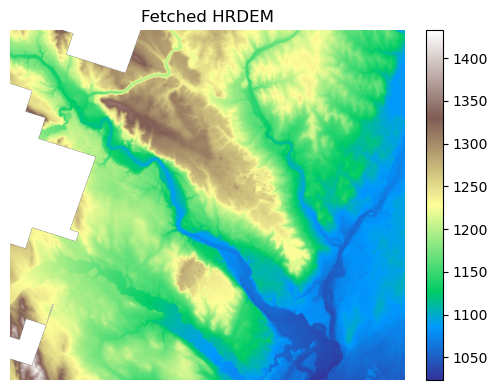

In [12]:
with rasterio.open(hrdem_fp) as src:
    preview_scale = max(src.height / 1024, src.width / 1024, 1)
    preview_shape = (
        max(1, int(src.height / preview_scale)),
        max(1, int(src.width / preview_scale)),
    )
    dem = src.read(1, out_shape=preview_shape, resampling=Resampling.bilinear).astype(float)
    if src.nodata is not None:
        dem[dem == src.nodata] = np.nan

plt.figure(figsize=(6, 4))
im = plt.imshow(dem, cmap="terrain")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Fetched HRDEM")
plt.axis("off")
plt.tight_layout()

print(f"DEM full shape: {src.shape}")
print(f"DEM preview shape: {dem.shape}")

## Visualize the Output

Output full shape: (36698, 41378)
Output preview shape: (908, 1024)


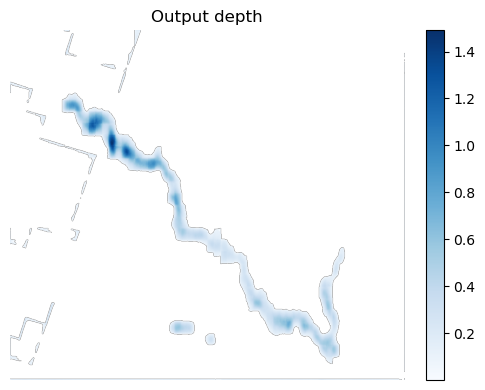

In [13]:
with rasterio.open(result_fp) as src:
    preview_scale = max(src.height / 1024, src.width / 1024, 1)
    preview_shape = (
        max(1, int(src.height / preview_scale)),
        max(1, int(src.width / preview_scale)),
    )
    result = src.read(1, out_shape=preview_shape, resampling=Resampling.bilinear).astype(float)
    if src.nodata is not None:
        result[result == src.nodata] = np.nan

plt.figure(figsize=(6, 4))
im = plt.imshow(np.where(result > 0, result, np.nan), cmap="Blues")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Output depth")
plt.axis("off")
plt.tight_layout()

print(f"Output full shape: {src.shape}")
print(f"Output preview shape: {result.shape}")